In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


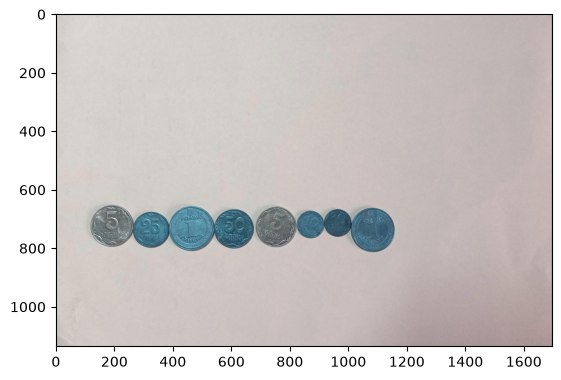

In [3]:
img = cv2.imread("coins.jpeg")

plt.imshow(img)

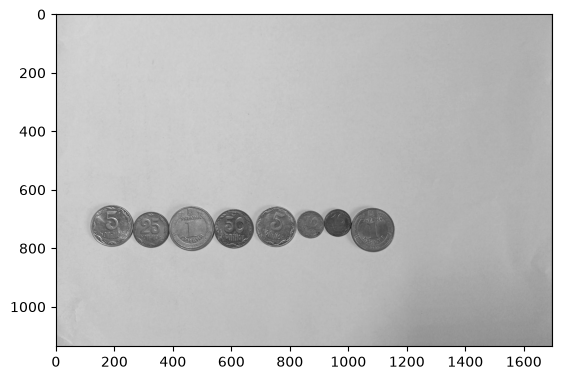

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')

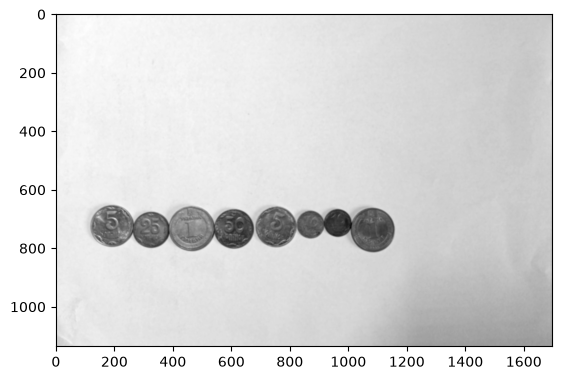

In [5]:
blurred = cv2.GaussianBlur(gray, (9, 9), 0)
#Розмиття для приберання шумів на зображені

plt.imshow(blurred, cmap='gray')

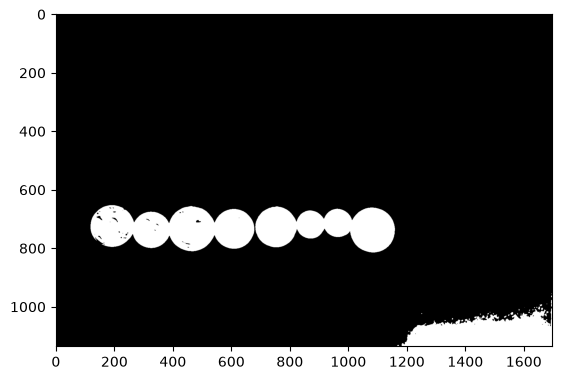

In [6]:
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.imshow(thresh, cmap='gray')

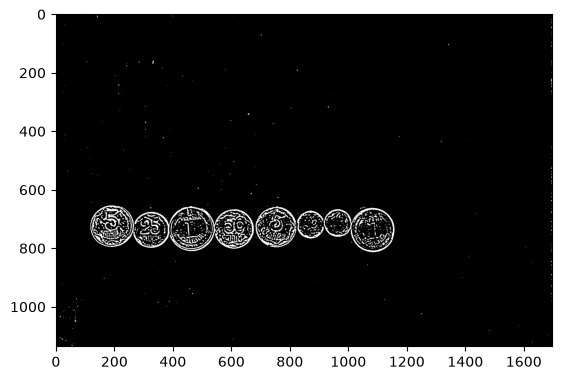

In [8]:
bin_img = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
#Я не знаю як прибрати цей шум в куті, тому я використав метод адаптивної бінаризації(Adaptive Thresholding)

plt.imshow(bin_img, cmap='gray')

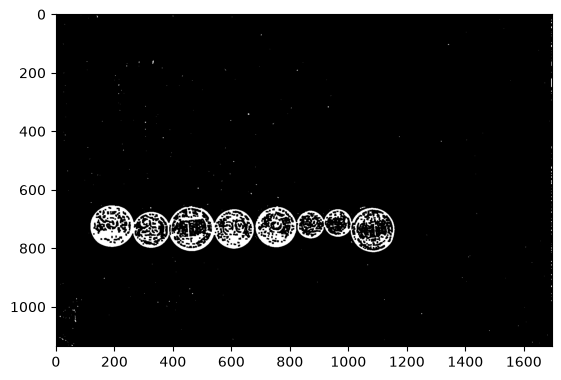

In [18]:
kernel = np.ones((5,5),np.uint8)

closing = cv2.morphologyEx(bin_img, cv2.MORPH_CLOSE, kernel,iterations = 1)
#Щоб монети не зникли при ерозії(зменшити монети щоб вони розліпились) треба їх наповнити білими пікселями, бо зараз тільки злиті тонкі контури

plt.imshow(closing, cmap='gray')

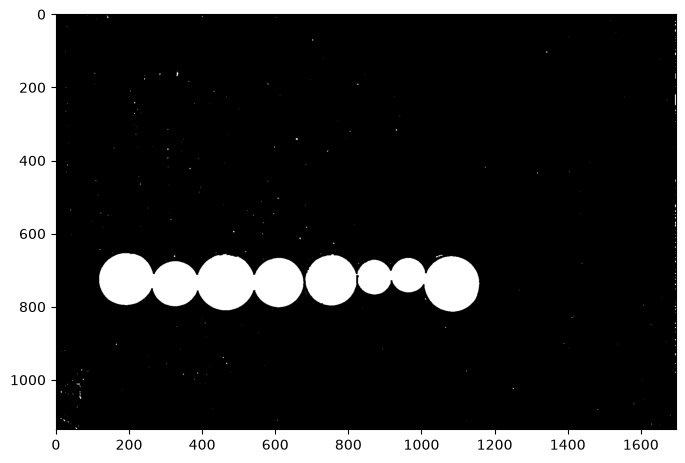

In [19]:
contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

filled_img = np.zeros_like(bin_img)

cv2.drawContours(filled_img, contours, -1, 255, thickness=-1)
# Заливаємо фарбою монети з товстими контурами

plt.figure(figsize=(8, 8))
plt.imshow(filled_img, cmap='gray')

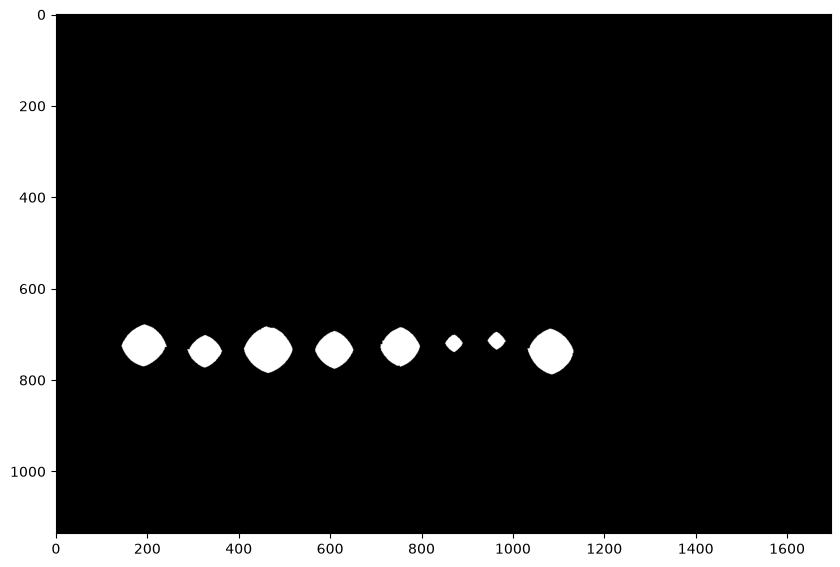

In [22]:
kernel = np.ones((5, 5), np.uint8)

eroded_img = cv2.erode(filled_img, kernel, iterations=11)
#Розліплюєм монети

plt.figure(figsize=(10, 8))
plt.imshow(eroded_img, cmap='gray')

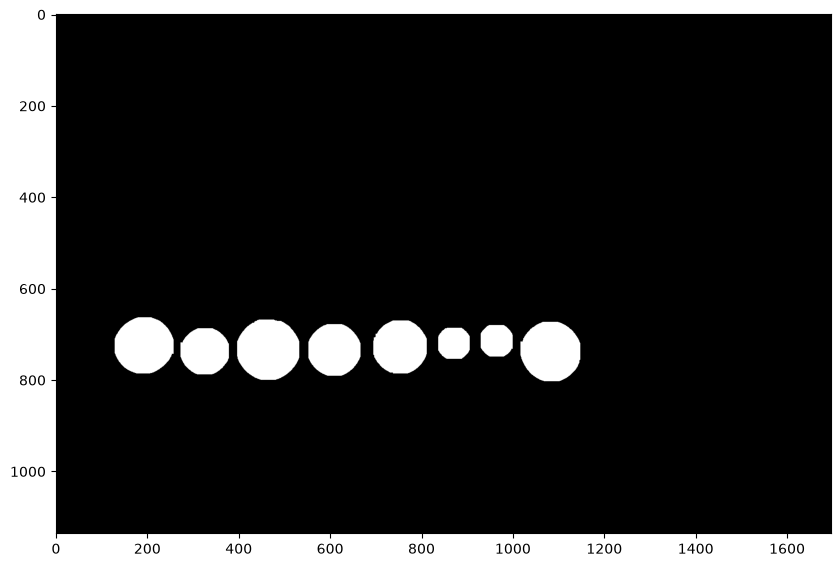

In [25]:
kernel = np.ones((11, 11), np.uint8)
dilation = cv2.dilate(eroded_img,kernel,iterations = 3)
#Збільшуємо монети для кращого підрахунку

plt.figure(figsize=(10, 8))
plt.imshow(dilation, cmap='gray')

In [24]:
contours, _ = cv2.findContours(dilation, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Рахування по контуру
min_area = 5 # Відсікання маленьких білих точок(шумів)
valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]

print(len(valid_contours)) 

8
